In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

First, let's look at a typical optimization problem using PyTorch and the autograd engine. We'll work with a very simple problem, finding the minimum of `y=(x-1)^2`, which we already know is 1. Let's look at a bare example of gradient descent first. If you know of Newton's Method, how does it compare to that?

In [2]:
def myfn(xs):
    # y = x^2 - 2x + 1
    # dy/dx = 2x - 2
    return (xs-1)**2

# Our initial guess is x = 10, and initial gradient is 18.
x = torch.tensor([10], dtype=torch.float32, requires_grad=True)
print(x)
y = myfn(x)
y.backward()
print(x.grad)

tensor([10.], requires_grad=True)
tensor([18.])


At 10.0, the slope is 36.0
Stepped x by 3.6, now 6.399999618530273


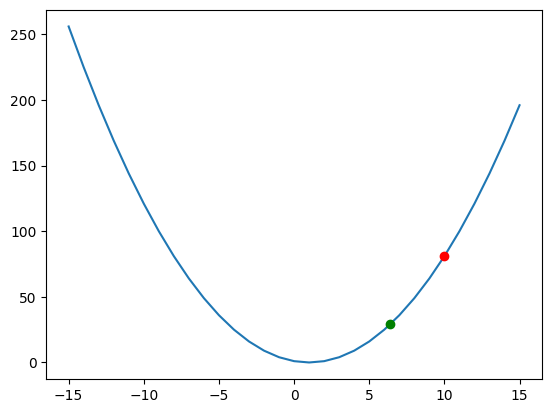

In [3]:
stepsz = 0.1

# Run one calculation of our quadratic function
y = myfn(x)
# backward() calculates the derivative using back propagation
# After calling backward, x.grad is set to dy/dx
y.backward()
print("At {}, the slope is {}".format(x.item(), x.grad.item()))

# Plot our quadratic function, and the current guess of the minimum
plotx = torch.arange(-15,16) # Left inclusive, right exclusive
ploty = myfn(plotx)
plt.plot(plotx, ploty)
plt.plot(x.detach(), y.detach(), 'ro')

# Step the parameter x by stepsz * the gradient. In this case we need to
# step AGAINST the gradient because we're looking for the minima.
x.data = x - stepsz * x.grad
print("Stepped x by {}, now {}".format(stepsz * x.grad.item(), x.item()))
x.grad = None
# Plot the new estimate after the step.
plt.plot(x.detach(), myfn(x.detach()), 'go')

# Run this cell as many times as you want; it will eventually make it to 1.
# Try again 

Everytime the previous cell is run, we step closer and closer to the minima. Try restarting the gradient descent process and set `stepsz` to a different value. How did things change? Do we still converge on the minima?

Next, we'll define a very simple custom function that we'll try to fit with a simple neural network. I chose a quadratic function, but it's worth coming back to this later and trying something more interesting, such as a transcendental function.

In [4]:
def qfunction(x: float) -> float:
    # return torch.cos(x) * x.abs()
    return 0.14 * x**2 - 0.57 * x + 1.2

Let's just see what this function looks like briefly.

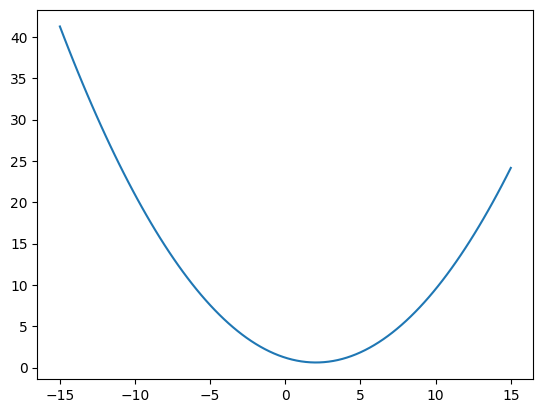

In [5]:
xs = torch.linspace(-15, 15, 100)
ys = qfunction(xs)
plt.plot(xs, ys)

Define a simple model that will try to fit our function. This model is simply Linear -> ReLU -> Linear.
ReLU is a specific non-linear function that works like this
`y = { 0 if x < 0, x if x > 0 }`

Any sequence of ONLY linear layers can be condensed into a single (probably larger) linear layer. Linear layers can each be written as a matrix multiplication, and any sequence of matrix multiplications can be condensed into one. Adding ReLU makes this no longer true; ReLU is non-linear and cannot be expressed by multiplication and addition alone. Non-linear functions (which you'll see referred to as activations) are added to networks so that they can approximate other non-linear functions.

In [9]:
# <EDIT THIS by adding more layers>
class MyNn(nn.Module):
    def __init__(self, features: int):
        super().__init__()
        self.lin1 = nn.Linear(1, features)
        self.inner0 = nn.Linear(features, features)
        # self.inner1 = nn.Linear(features, features)
        # self.inner2 = nn.Linear(features, features)
        self.lin2 = nn.Linear(features, 1)

    def forward(self, x):
        x = self.lin1(x)
        x = F.relu(x)
        x = self.inner0(x)
        x = F.relu(x)
        # x = self.inner1(x)
        # x = F.relu(x)
        # x = self.inner2(x)
        # x = F.relu(x)
        x = self.lin2(x)
        return x
        

1250 Steps
Final loss of 3.3212039470672607
0.01


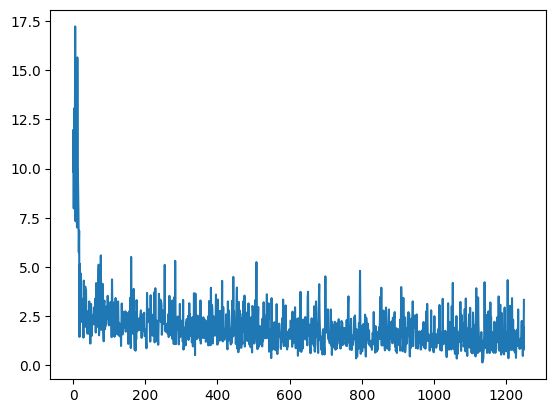

In [15]:
# Features defines how "big" the network is, that is, how many internal weights it can leverage.
# <EDIT THIS>
model = MyNn(features = 4)

# L1 Loss is calculated as the mean of the absolute difference between the prediction and label.
# So simply, l1loss = mean(|label - pred|)
def l1loss(pred, label):
    diff = (pred - label).abs()
    return diff.mean()

# We define a batchsize of 8. An entire batch of samples is run through the model on each iteration
batchsize = 8

# Samples. We simulate having this many data points TOTAL available to us.
# Even if grouped into larger batches, keep the total number of points roughly constant
# This simulates a finite dataset of size 10000
step = 10000 // batchsize
print(step, "Steps")

# Learning rate affects the magnitude of each optimization step
# Try modifying this loop to reduce the learning rate by a small amount over time.
# <EDIT THIS>
lr = 0.01

s_num = []
losses = []
# <EDIT THIS>
for x in range(step):
    # rand returns between 0 and 1, so the shift and scale
    # sets the range to be between -15 and 15.
    input = (torch.rand(batchsize, 1) - 0.5) * 30
    # input = torch.randint(-150, 151, (batchsize, 1)).float() / 10
    label = qfunction(input)

    # model(value) is the same as calling model.forward(value) IN THIS CASE but the
    # first form that does NOT call forward explicitly is the correct method.
    # 
    pred = model(input)
    loss = l1loss(pred, label)
    loss.backward()

    # Most basic possible optimizer: Step every parameter down by the gradient * LR
    for p in model.parameters():
        p.data = p - p.grad * lr
        p.grad = None

    s_num.append(x)
    losses.append(loss.item())
    # <EDIT THIS>
    lr = lr * 1.0
    
print("Final loss of {}".format(loss))
print(lr)
plt.plot(s_num, losses)

torch.Size([100, 1])


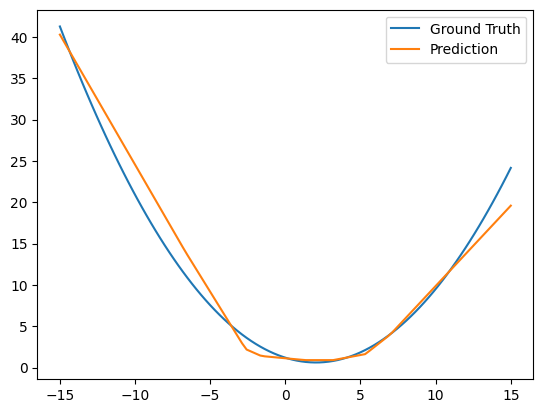

In [16]:
model.eval()
with torch.no_grad():
    ps = model(xs.unsqueeze(-1))
    print(ps.shape)

plt.plot(xs, ys, label='Ground Truth')
plt.plot(xs, ps.flatten(), label='Prediction')
plt.legend()

You may need to run the previous cell several times to draw a good solution, but the parameters here do produce something that looks like our function. Let's briefly review the initial parameters:
* 10000 samples, in a batch size of 8, for 1250 optimizer steps/parameter updates.
* Constant Learning Rate of 0.01
* Linear model with one hidden layer of size 4
* L1 Loss

Now, try changing these parameters to find a better fit for the quadratic function.

### A solution
35000 samples, batchsize of 64
LR starts at 0.1, decays to LR*0.99 on each step
Hidden size of 128, 3 inner layers
L1 Loss

## Helpful free readings
* A great introductory text for Python: https://greenteapress.com/thinkpython/html/index.html
* More about Colab and Jupyter: https://colab.research.google.com/github/fastai/fastbook/blob/master/app_jupyter.ipynb
* Fastai's intro to machine learning: https://colab.research.google.com/github/fastai/fastbook/blob/master/01_intro.ipynb
* Provides more detail and a clear writeup of gradient descent and optimization: https://colab.research.google.com/github/fastai/fastbook/blob/master/04_mnist_basics.ipynb

# As homework...
* Replace the quadratic function with one of your own, and try to fit it with the initial parameters listed in the above cell. If the initial parameters fit your function well, add more complexity to your function. Make sure your function uses operators that cannot be replaced fully by multiplication and addition, such as sine, cosine, logs, etc.
* Now modify the parameters to your liking, and try to find the "smallest" configuration that produces a good fit, where smallest uses the fewest iterations, fewest hidden layers, and lowest dimension in each hidden layer. Take a screenshot of the final plot that compares the model approximation to the function.